In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import chi2


# 1 - **Preprocessing**

In [ ]:
# load dataset
df = pd.read_csv("/content/CustomerChurn.csv")

# check info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7043 non-null   int64  
 1   Customer ID        7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure             7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [ ]:
df["Churn"].value_counts()
#imbalance


,count
Churn,
No,5174
Yes,1869


In [ ]:
#drop irrelvent coulmns (loyalty id , Customer id)
df.drop(["Customer ID", "LoyaltyID"], axis=1, inplace=True)

In [ ]:
#Fixing datatype
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.fillna(df['Total Charges'].median(), inplace=True)

#encide catogrical features
encoder = LabelEncoder()
for feature in df.columns:
    if df[feature].dtype == 'object':
        df[feature] = encoder.fit_transform(df[feature])

In [ ]:
print(df.isnull().sum()) # no null values

Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Senior Citizen     7043 non-null   int64  
 1   Partner            7043 non-null   int64  
 2   Dependents         7043 non-null   int64  
 3   Tenure             7043 non-null   int64  
 4   Phone Service      7043 non-null   int64  
 5   Multiple Lines     7043 non-null   int64  
 6   Internet Service   7043 non-null   int64  
 7   Online Security    7043 non-null   int64  
 8   Online Backup      7043 non-null   int64  
 9   Device Protection  7043 non-null   int64  
 10  Tech Support       7043 non-null   int64  
 11  Streaming TV       7043 non-null   int64  
 12  Streaming Movies   7043 non-null   int64  
 13  Contract           7043 non-null   int64  
 14  Paperless Billing  7043 non-null   int64  
 15  Payment Method     7043 non-null   int64  
 16  Monthly Charges    7043 

In [ ]:
#split the dataset

X = df.drop('Churn', axis=1)
y = df['Churn']


# **2 - Correlation Analysis**

In [ ]:
import pandas as pd

corr = df.corr()['Churn'].drop('Churn')

print("Highest Positive:")
print(corr.idxmax(), ":", corr.max())

print("\nHighest Negative:")
print(corr.idxmin(), ":", corr.min())

Highest Positive:
Monthly Charges : 0.19335642223784716

Highest Negative:
Contract : -0.39671262920984274


# **3 - Training 3 Algorithm ( - DT , RF , Boosting )**

In [ ]:
# StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_model(model, X, y):
    acc_list = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc_list.append(accuracy_score(y_test, y_pred))


    print("-----")
    print(model.__class__.__name__)
    print("Accuracy :", np.mean(acc_list))
    print("-----\n")


# MODELS

# Decision Tree
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
)


# Run all models

evaluate_model(dt, X, y)
evaluate_model(rf, X, y)
evaluate_model(gb, X, y)

-----
DecisionTreeClassifier
Accuracy : 0.7821951214594491
-----

-----
RandomForestClassifier
Accuracy : 0.7746678213110523
-----

-----
GradientBoostingClassifier
Accuracy : 0.8009348385379702
-----



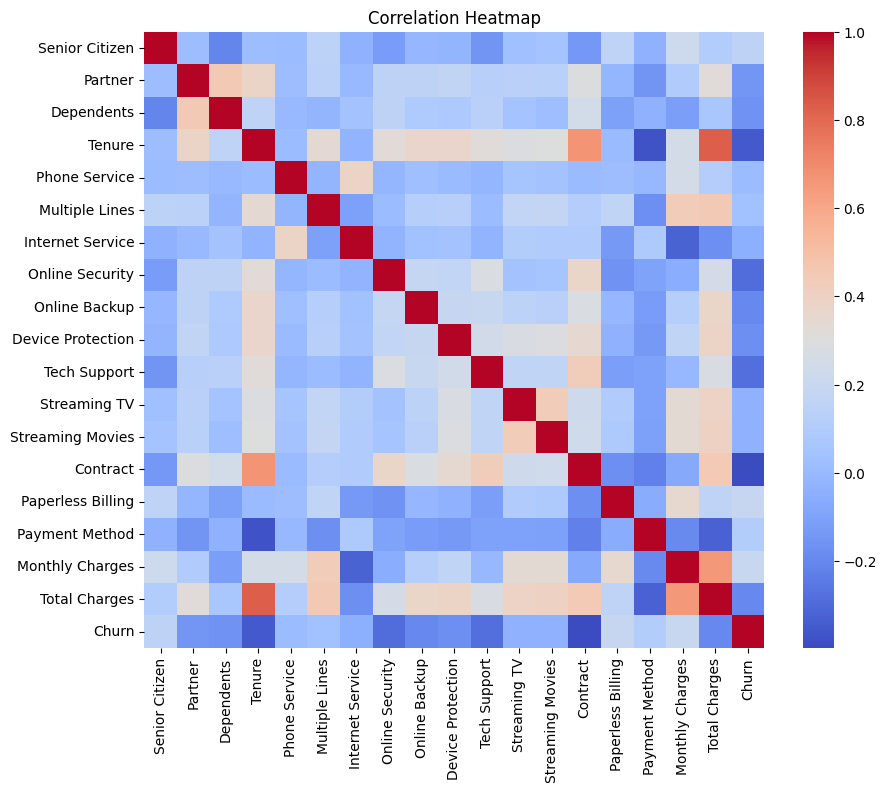

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()